In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
%matplotlib inline

In [12]:

# Load the dataset
df = pd.read_csv('../data/benin-malanville.csv')
print(df.head())  # Display first 5 rows



          Timestamp  GHI  DNI  DHI  ModA  ModB  Tamb    RH   WS  WSgust  \
0  2021-08-09 00:01 -1.2 -0.2 -1.1   0.0   0.0  26.2  93.4  0.0     0.4   
1  2021-08-09 00:02 -1.1 -0.2 -1.1   0.0   0.0  26.2  93.6  0.0     0.0   
2  2021-08-09 00:03 -1.1 -0.2 -1.1   0.0   0.0  26.2  93.7  0.3     1.1   
3  2021-08-09 00:04 -1.1 -0.1 -1.0   0.0   0.0  26.2  93.3  0.2     0.7   
4  2021-08-09 00:05 -1.0 -0.1 -1.0   0.0   0.0  26.2  93.3  0.1     0.7   

   WSstdev     WD  WDstdev   BP  Cleaning  Precipitation  TModA  TModB  \
0      0.1  122.1      0.0  998         0            0.0   26.3   26.2   
1      0.0    0.0      0.0  998         0            0.0   26.3   26.2   
2      0.5  124.6      1.5  997         0            0.0   26.4   26.2   
3      0.4  120.3      1.3  997         0            0.0   26.4   26.3   
4      0.3  113.2      1.0  997         0            0.0   26.4   26.3   

   Comments  
0       NaN  
1       NaN  
2       NaN  
3       NaN  
4       NaN  


In [13]:
# Convert Timestamp to datetime
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
print(df.dtypes)  # Verify Timestamp is datetime64

Timestamp        datetime64[ns]
GHI                     float64
DNI                     float64
DHI                     float64
ModA                    float64
ModB                    float64
Tamb                    float64
RH                      float64
WS                      float64
WSgust                  float64
WSstdev                 float64
WD                      float64
WDstdev                 float64
BP                        int64
Cleaning                  int64
Precipitation           float64
TModA                   float64
TModB                   float64
Comments                float64
dtype: object


In [17]:
# Summary statistics for numeric columns
summary_stats = df.describe()
print(summary_stats)

# Missing values report
missing_values = df.isna().sum()
missing_percentage = (df.isna().sum() / len(df)) * 100
missing_report = pd.DataFrame({'Missing Values': missing_values, 'Percentage': missing_percentage})
print(missing_report[missing_report['Percentage'] > 5])  # Columns with >5% missing

                           Timestamp            GHI            DNI  \
count                         525600  525600.000000  525600.000000   
mean   2022-02-07 12:00:30.000000512     240.559452     167.187516   
min              2021-08-09 00:01:00     -12.900000      -7.800000   
25%              2021-11-08 06:00:45      -2.000000      -0.500000   
50%              2022-02-07 12:00:30       1.800000      -0.100000   
75%              2022-05-09 18:00:15     483.400000     314.200000   
max              2022-08-09 00:00:00    1413.000000     952.300000   
std                              NaN     331.131327     261.710501   

                 DHI           ModA           ModB           Tamb  \
count  525600.000000  525600.000000  525600.000000  525600.000000   
mean      115.358961     236.589496     228.883576      28.179683   
min       -12.600000       0.000000       0.000000      11.000000   
25%        -2.100000       0.000000       0.000000      24.200000   
50%         1.600000    

In [18]:
key_columns = ['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'WS', 'WSgust']
z_scores = df[key_columns].apply(zscore, nan_policy='omit')
outliers = (z_scores.abs() > 3).any(axis=1)
print(f"Number of outlier rows: {outliers.sum()}")

Number of outlier rows: 7740


In [20]:
key_columns = ['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'WS', 'WSgust']
for col in key_columns:
    df[col] = df[col].fillna(df[col].median())

In [21]:
df.dropna(subset=key_columns, inplace=True)

In [22]:
df_clean = df[~outliers]

C:\Users\samra\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


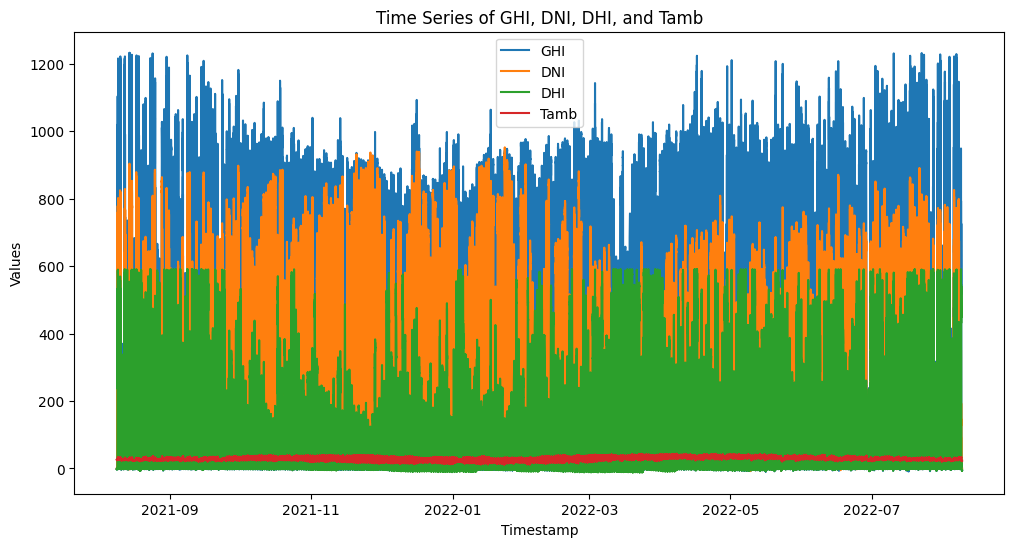

In [25]:
plt.figure(figsize=(12, 6))
plt.plot(df_clean['Timestamp'], df_clean['GHI'], label='GHI')
plt.plot(df_clean['Timestamp'], df_clean['DNI'], label='DNI')
plt.plot(df_clean['Timestamp'], df_clean['DHI'], label='DHI')
plt.plot(df_clean['Timestamp'], df_clean['Tamb'], label='Tamb')
plt.xlabel('Timestamp')
plt.ylabel('Values')
plt.title('Time Series of GHI, DNI, DHI, and Tamb')
plt.legend()
plt.show()

C:\Users\samra\AppData\Local\Temp\ipykernel_30688\770286325.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Month'] = df_clean['Timestamp'].dt.month


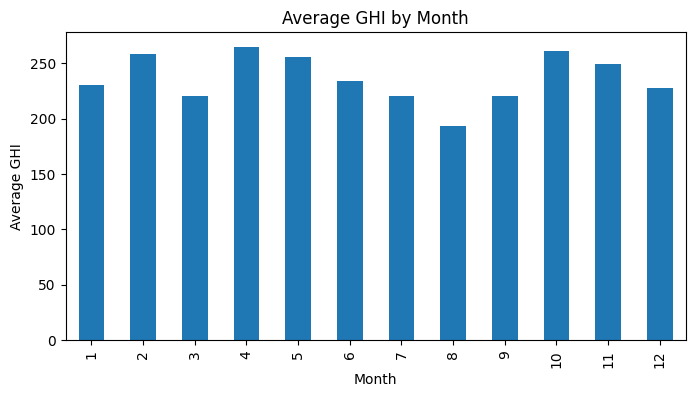

In [24]:
df_clean['Month'] = df_clean['Timestamp'].dt.month
monthly_ghi = df_clean.groupby('Month')['GHI'].mean()
plt.figure(figsize=(8, 4))
monthly_ghi.plot(kind='bar')
plt.xlabel('Month')
plt.ylabel('Average GHI')
plt.title('Average GHI by Month')
plt.show()

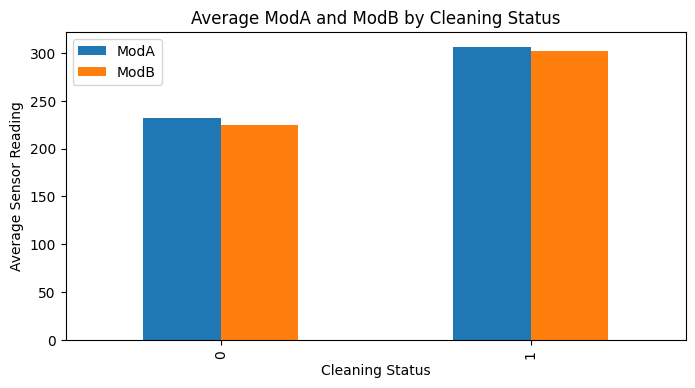

In [26]:
cleaning_impact = df_clean.groupby('Cleaning')[['ModA', 'ModB']].mean()
cleaning_impact.plot(kind='bar', figsize=(8, 4))
plt.xlabel('Cleaning Status')
plt.ylabel('Average Sensor Reading')
plt.title('Average ModA and ModB by Cleaning Status')
plt.show()

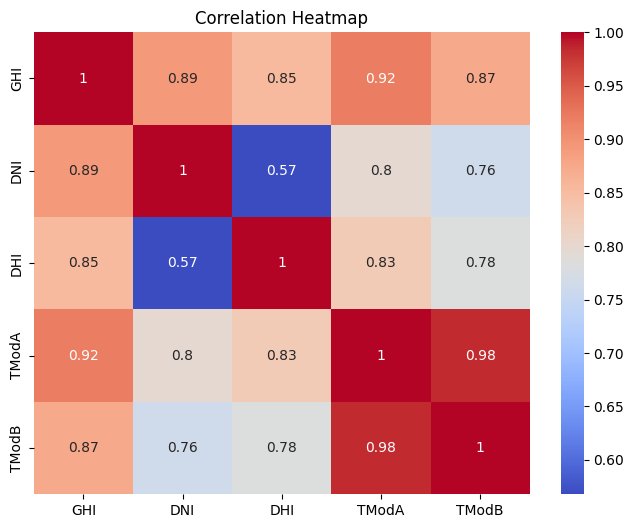

In [27]:
corr_columns = ['GHI', 'DNI', 'DHI', 'TModA', 'TModB']
corr_matrix = df_clean[corr_columns].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

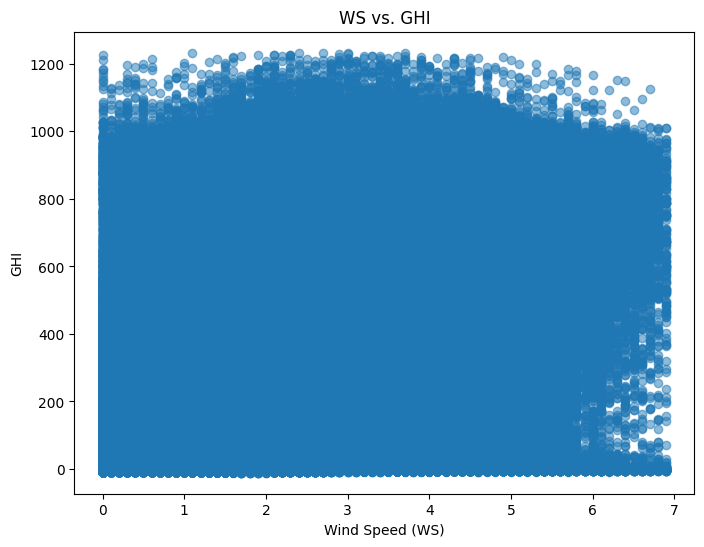

In [28]:
plt.figure(figsize=(8, 6))
plt.scatter(df_clean['WS'], df_clean['GHI'], alpha=0.5)
plt.xlabel('Wind Speed (WS)')
plt.ylabel('GHI')
plt.title('WS vs. GHI')
plt.show()

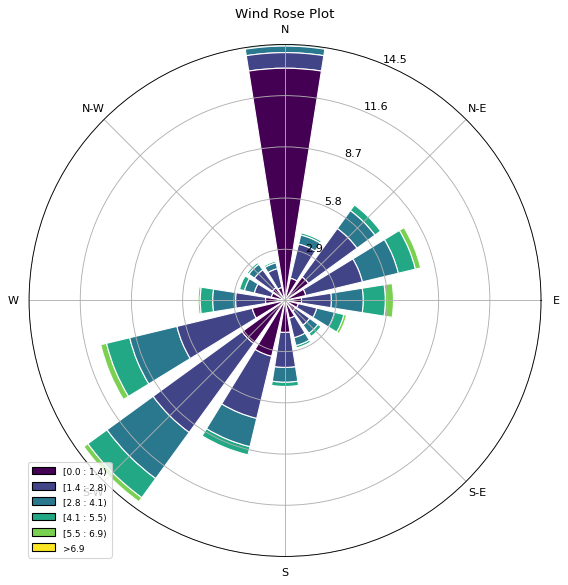

In [29]:
from windrose import WindroseAxes
ax = WindroseAxes.from_ax()
ax.bar(df_clean['WD'], df_clean['WS'], normed=True, opening=0.8, edgecolor='white')
ax.set_legend()
plt.title('Wind Rose Plot')
plt.show()

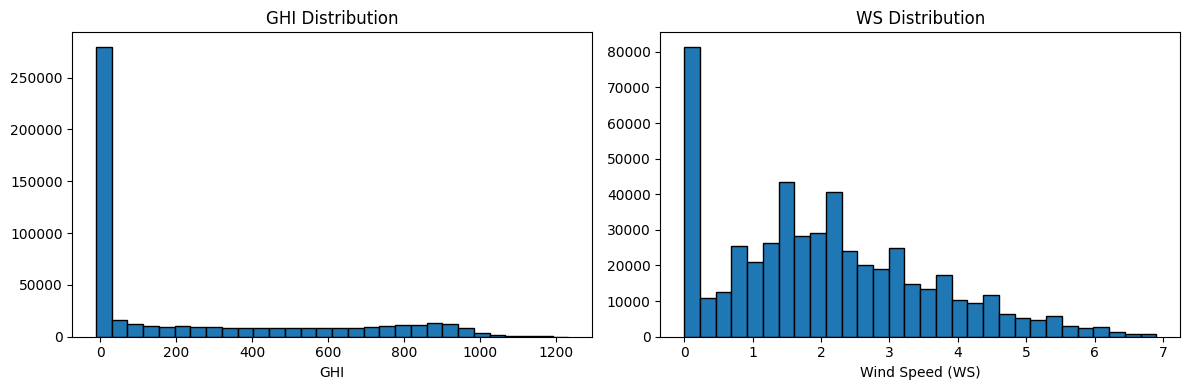

In [30]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(df_clean['GHI'], bins=30, edgecolor='black')
plt.xlabel('GHI')
plt.title('GHI Distribution')
plt.subplot(1, 2, 2)
plt.hist(df_clean['WS'], bins=30, edgecolor='black')
plt.xlabel('Wind Speed (WS)')
plt.title('WS Distribution')
plt.tight_layout()
plt.show()

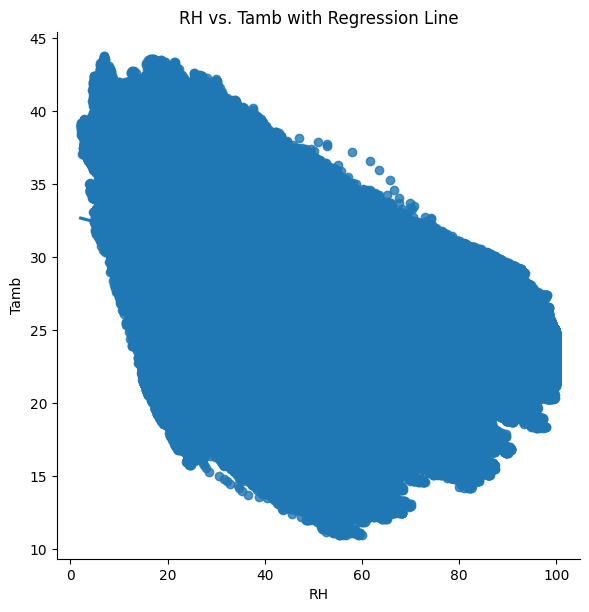

In [35]:
sns.lmplot(x='RH', y='Tamb', data=df_clean, height=6)
plt.title('RH vs. Tamb with Regression Line')
plt.show()

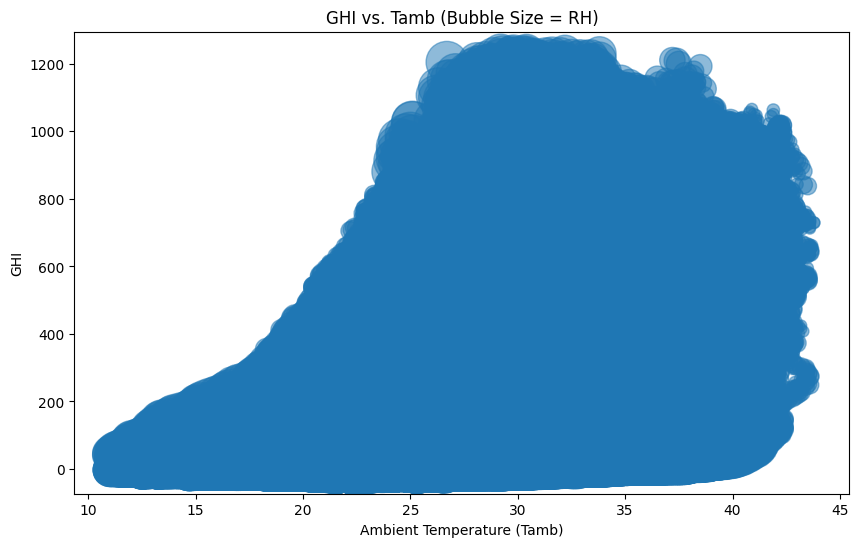

In [36]:
plt.figure(figsize=(10, 6))
plt.scatter(df_clean['Tamb'], df_clean['GHI'], s=df_clean['RH']*10, alpha=0.5)
plt.xlabel('Ambient Temperature (Tamb)')
plt.ylabel('GHI')
plt.title('GHI vs. Tamb (Bubble Size = RH)')
plt.show()

In [ ]:
df_clean.to_csv('../data/benin_clean.csv', index=False)